# Customer Segmentation

This project focuses on customer segmentation using customer demographic and spending data. The dataset contains information such as customer ID, gender, age, annual income, and spending score. Additional features, such as age group, cluster, and customer segment, were created to better understand customer behavior patterns.

Using clustering techniques, customers were grouped into different segments based on their income and spending habits. For example, some customers were classified as “Low Value” customers because they have lower spending scores, while others were labeled “Impulsive” due to their high spending behavior despite lower income levels.

The main goal of the project is to help businesses understand their customers better, improve targeted marketing strategies, and make data-driven decisions that can increase customer satisfaction and sales.

In [1]:
pip install flask

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pickle
from flask import Flask, request, jsonify

In [3]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.shape

(200, 5)

Total number of null values in each column

In [5]:
df.isna().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Columns data types

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


Average Spending Score by Gender

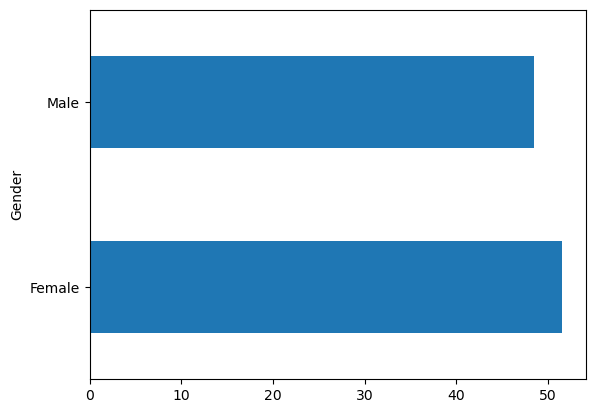

In [7]:
df.groupby("Gender")["Spending Score (1-100)"].mean().plot(kind="barh");

Annual Income vs Spending Score by Gender

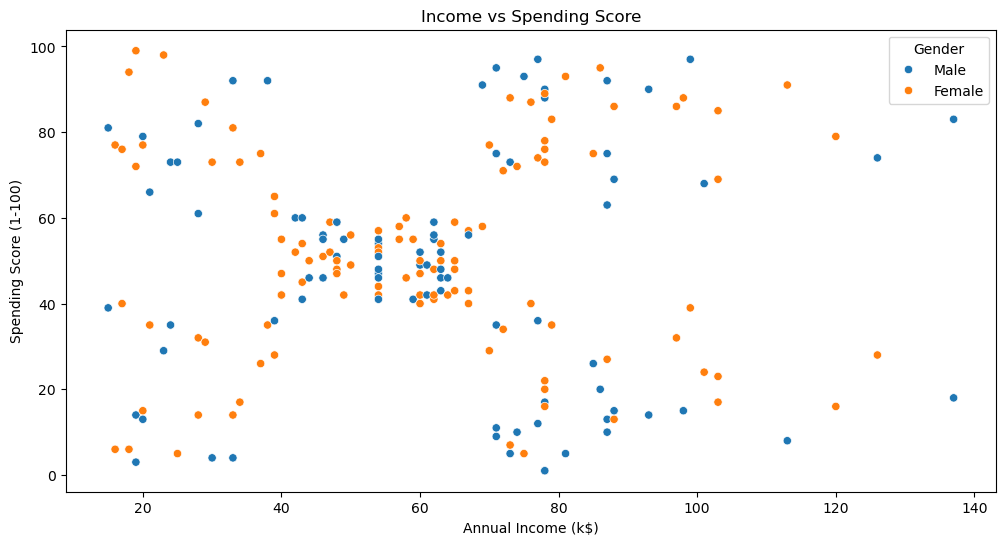

In [8]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x="Annual Income (k$)", 
            y="Spending Score (1-100)",
            hue="Gender",
            data=df)
plt.title("Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show();
           

Create Age Groups column

In [9]:
bins = [0, 10, 20, 30, 40, 50, 60, 70]
labels = ["0-10", "11-20", "21-30", "31-40", "41-50", "51-60", "61-70"]

df["Age Group"] = pd.cut(df["Age"], bins=bins, labels=labels)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Age Group
0,1,Male,19,15,39,11-20
1,2,Male,21,15,81,21-30
2,3,Female,20,16,6,11-20
3,4,Female,23,16,77,21-30
4,5,Female,31,17,40,31-40


Average Spending Score by Age Group

C:\Users\USER\AppData\Local\Temp\ipykernel_22548\735722374.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Age Group")["Spending Score (1-100)"].mean().plot(kind="barh")


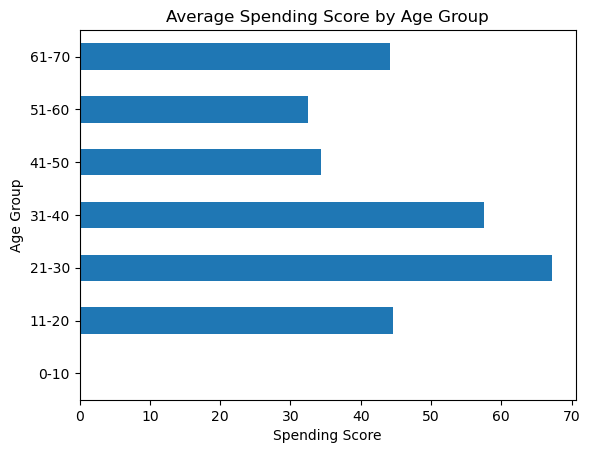

In [10]:
df.groupby("Age Group")["Spending Score (1-100)"].mean().plot(kind="barh")

plt.title("Average Spending Score by Age Group")
plt.xlabel("Spending Score")
plt.ylabel("Age Group")
plt.show()

Average Annual Income by Age Group

C:\Users\USER\AppData\Local\Temp\ipykernel_22548\1938029332.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Age Group")["Annual Income (k$)"].mean().plot(kind="barh")


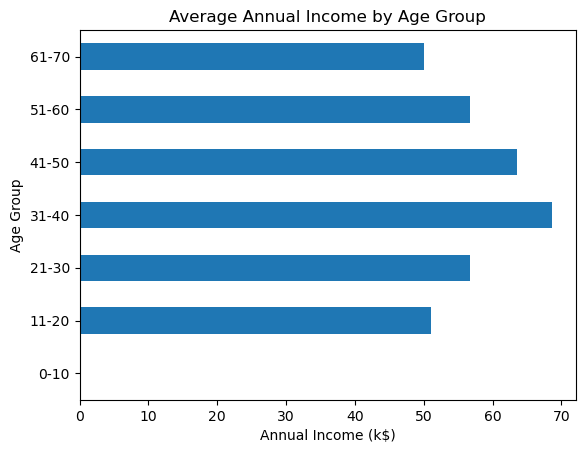

In [11]:
df.groupby("Age Group")["Annual Income (k$)"].mean().plot(kind="barh")

plt.title("Average Annual Income by Age Group")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Age Group")
plt.show()

In [12]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]
X

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

C:\Users\USER\anaconda3\envs\MachineLearningDataScience\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\USER\anaconda3\envs\MachineLearningDataScience\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\USER\anaconda3\envs\MachineLearningDataScience\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\USER\anaconda3\envs\MachineLearnin

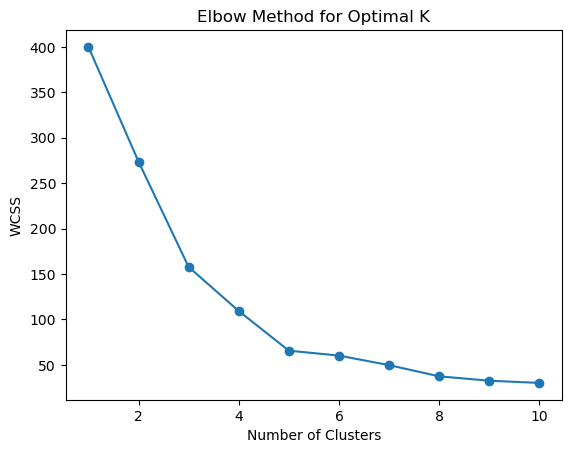

In [14]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [15]:
kmeans = KMeans(n_clusters=5, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

C:\Users\USER\anaconda3\envs\MachineLearningDataScience\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


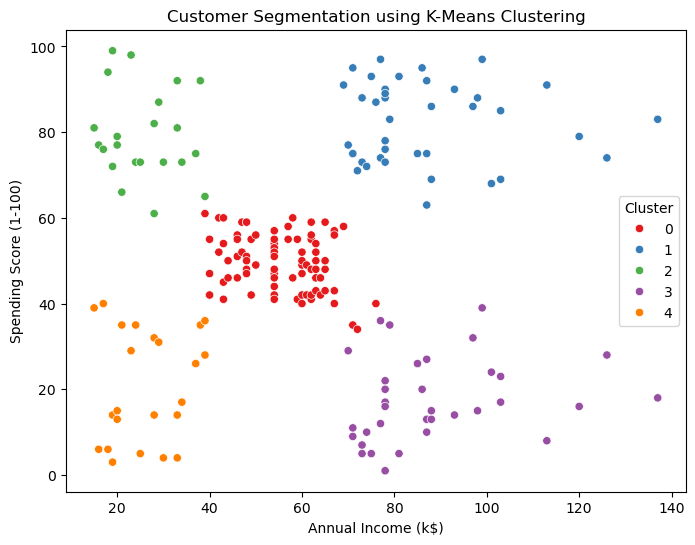

In [16]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set1",
    data=df
)

plt.title("Customer Segmentation using K-Means Clustering")
plt.show()

In [17]:
df.groupby("Cluster")[["Annual Income (k$)", "Spending Score (1-100)"]].mean()

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


In [18]:
cluster_names = {
    0: "Average",
    1: "VIP",
    2: "Impulsive",
    3: "Careful",
    4: "Low Value"
}

df["Customer Segment"] = df["Cluster"].map(cluster_names)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Age Group,Cluster,Customer Segment
0,1,Male,19,15,39,11-20,4,Low Value
1,2,Male,21,15,81,21-30,2,Impulsive
2,3,Female,20,16,6,11-20,4,Low Value
3,4,Female,23,16,77,21-30,2,Impulsive
4,5,Female,31,17,40,31-40,4,Low Value


In [19]:
pickle.dump(kmeans, open("kmeans.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [21]:
# !cd "C:\Users\USER\Projects\Customer Segmentation"